<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
!pip install gdown -q

In [2]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=4c5198a3-91da-40a7-9e5d-efccdadf952f
To: /content/Data.zip
100%|██████████| 289M/289M [00:09<00:00, 31.0MB/s]


'Data.zip'

In [3]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [11]:
!pip install scikit-uplift==0.2.0 causalml optuna

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklift.models import SoloModel, ClassTransformation
from sklift.metrics import qini_auc_score
from sklift.viz import plot_qini_curve, plot_uplift_curve
from causalml.inference.tree import UpliftRandomForestClassifier
import optuna

In [8]:
DATA_PATH = '/content/HW_UPLIFT/'

features  = pd.read_csv(DATA_PATH + 'AGGS_FINAL.csv')
campaigns = pd.read_csv(DATA_PATH + 'CAMPAINGS.csv')
people = pd.read_csv(DATA_PATH + 'PEOPLE_IN_CAMPAINGS_FINAL.csv')
contracts = pd.read_csv(DATA_PATH + 'CONTRACTS_FINAL.csv')

people['delivery_date'] = pd.to_datetime(people['delivery_date'], errors='coerce')
contracts['contract_date'] = pd.to_datetime(contracts['contract_date'], errors='coerce')

print('unique product_id in campaigns:', campaigns['product_id'].unique())
print('unique product_id in contracts:', contracts['product_id'].unique())

campaigns_p = campaigns[campaigns['product_id'] == 1].copy()
contracts_p = contracts[contracts['product_id'] == 1].copy()

people = people.rename(columns={'t_flag': 'is_treatment'})

camp = people.merge(
  campaigns_p,
  on='campaing_id',
  how='left',
  validate='m:1'
)

treat_valid = camp[(camp['is_treatment'] == 1) & camp['delivery_date'].notna()].copy()
treat_valid['campaign_month_start'] = treat_valid['delivery_date'].dt.to_period('M').dt.start_time

campaign_month_start = (treat_valid.groupby('campaing_id')['campaign_month_start'].first().reset_index())

camp = camp.merge(
  campaign_month_start,
  on='campaing_id',
  how='left',
  validate='m:1'
)

df = camp.merge(
  contracts_p[['user_id', 'product_id', 'contract_date']],
  on=['user_id', 'product_id'],
  how='left'
)

df['target_raw'] = 0
mask_treat = df['is_treatment'] == 1
mask_ctrl  = df['is_treatment'] == 0

cond_treat = (
  (df['contract_date'] >= df['delivery_date']) &
  (df['contract_date'] <  df['delivery_date'] + timedelta(days=14))
)

cond_ctrl = (
  (df['contract_date'] >= df['campaign_month_start']) &
  (df['contract_date'] <  df['campaign_month_start'] + timedelta(days=21))
)

df.loc[mask_treat & cond_treat, 'target_raw'] = 1
df.loc[mask_ctrl  & cond_ctrl,  'target_raw'] = 1

df_target = (
  df.groupby(['user_id', 'campaing_id', 'channel','is_treatment', 'campaign_month_start'],
             as_index=False)['target_raw']
  .max()
  .rename(columns={'target_raw': 'target'})
)

df_target['report_dt'] = (
  (df_target['campaign_month_start'].dt.to_period('M') - 2)
  .dt.to_timestamp('M')
)

print('df_target shape:', df_target.shape)
print('target distribution:')
print(df_target['target'].value_counts())

agg_campaign = (
  df_target
  .groupby(['campaing_id', 'channel', 'is_treatment'], as_index=False)
  .agg(conv=('target', 'mean'),
        n=('target', 'size'))
)

pivot_campaign = agg_campaign.pivot(
  index=['campaing_id', 'channel'],
  columns='is_treatment',
  values=['conv', 'n']
)

pivot_campaign.columns = [
  f'{m}_{"control" if g == 0 else "treat"}'
  for (m, g) in pivot_campaign.columns
]

pivot_campaign = pivot_campaign.reset_index()
pivot_campaign['uplift'] = pivot_campaign['conv_treat'] - pivot_campaign['conv_control']

print('uplift по кампаниям:')
pivot_campaign.sort_values('uplift', ascending=False).head(10)

unique product_id in campaigns: [1]
unique product_id in contracts: [1]
df_target shape: (520000, 7)
target distribution:
target
0    282110
1    237890
Name: count, dtype: int64
uplift по кампаниям:


,campaing_id,channel,conv_control,conv_treat,n_control,n_treat,uplift
1,iddqd,push,0.202150,0.601738,80000.0,80000.0,0.399588
2,iddt,banner,0.400733,0.602717,60000.0,60000.0,0.201983
3,idkfa,other_ads,0.400733,0.602717,60000.0,60000.0,0.201983
0,idclip,sms,0.684917,0.201167,60000.0,60000.0,-0.483750


### ваши выводы здесь

1. Push показывает самый высокий uplift ($+0.40$), баннеры и реклама дают умеренный прирост ($\approx +0.20$), SMS имеет отрицательный uplift ($-0.48$), что делает SMS кандидатом на исключение

2. Для SMS наблюдается высокая конверсия в контрольной группе, что может указывать на неверные даты или некорректную выборку

3. Неэффективные кампании можно исключить из обучения uplift-моделей, чтобы избежать искажения результатов и утечки информации

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [10]:
features['report_dt'] = pd.to_datetime(features['report_dt'], errors='coerce')

df_model = df_target.merge(
  features,
  on=['user_id', 'report_dt'],
  how='left',
  validate='m:1'
)

print('df_model shape после join с фичами:', df_model.shape)

if 'x1' in df_model.columns:
  print('Доля строк без агрегатов:',
        df_model['x1'].isna().mean())

num_base = [c for c in df_model.columns if c.startswith('x')]
if 'age' in df_model.columns:
    num_base.append('age')

df_model = df_model.dropna(subset=num_base).copy()
print('df_model shape после удаления NaN в фичах:', df_model.shape)

#uplift EDА

agg = (
  df_model
  .groupby(['campaing_id', 'channel', 'is_treatment'], as_index=False)
  .agg(conv=('target', 'mean'),
        n=('target', 'size'))
)

pivot = agg.pivot(
  index=['campaing_id', 'channel'],
  columns='is_treatment',
  values=['conv', 'n']
)

pivot.columns = [
  f'{m}_{"control" if g == 0 else "treat"}'
  for (m, g) in pivot.columns
]
pivot = pivot.reset_index()
pivot['uplift'] = pivot['conv_treat'] - pivot['conv_control']

MIN_N = 100
pivot['broken_reason'] = ''

pivot.loc[pivot['n_treat'] < MIN_N, 'broken_reason'] += 'low_treat; '
pivot.loc[pivot['n_control'] < MIN_N, 'broken_reason'] += 'low_control; '
pivot.loc[(pivot['conv_treat'] == 0) & (pivot['conv_control'] == 0),
          'broken_reason'] += 'no_conversions; '

ratio = pivot['n_treat'] / (pivot['n_control'] + 1e-9)
pivot.loc[(ratio < 0.1) | (ratio > 10), 'broken_reason'] += 'unbalanced_groups; '

broken_campaigns = pivot[pivot['broken_reason'] != '']
ok_campaigns = pivot[pivot['broken_reason'] == '']

print('Некорректные кампании:')
display(broken_campaigns)

print('Корректные кампании:')
display(ok_campaigns)

df_model_ok = df_model[df_model['campaing_id'].isin(ok_campaigns['campaing_id'])].copy()
print('df_model_ok shape:', df_model_ok.shape)

#uplift по каналам
agg_channel = (
    df_model_ok
    .groupby(['channel', 'is_treatment'], as_index=False)
    .agg(conv=('target', 'mean'),
         n=('target', 'size'))
)

ch_pivot = agg_channel.pivot(
    index='channel',
    columns='is_treatment',
    values=['conv', 'n']
)

ch_pivot.columns = [
    f'{m}_{"control" if g == 0 else "treat"}'
    for (m, g) in ch_pivot.columns
]
ch_pivot = ch_pivot.reset_index()
ch_pivot['uplift'] = ch_pivot['conv_treat'] - ch_pivot['conv_control']

print('Uplift по каналам:')
display(ch_pivot.sort_values('uplift', ascending=False))

df_model shape после join с фичами: (520000, 19)
Доля строк без агрегатов: 0.0
df_model shape после удаления NaN в фичах: (520000, 19)
Некорректные кампании:


,campaing_id,channel,conv_control,conv_treat,n_control,n_treat,uplift,broken_reason


Корректные кампании:


,campaing_id,channel,conv_control,conv_treat,n_control,n_treat,uplift,broken_reason
0,idclip,sms,0.684917,0.201167,60000.0,60000.0,-0.483750,
1,iddqd,push,0.202150,0.601738,80000.0,80000.0,0.399588,
2,iddt,banner,0.400733,0.602717,60000.0,60000.0,0.201983,
3,idkfa,other_ads,0.400733,0.602717,60000.0,60000.0,0.201983,


df_model_ok shape: (520000, 19)
Uplift по каналам:


,channel,conv_control,conv_treat,n_control,n_treat,uplift
2,push,0.202150,0.601738,80000.0,80000.0,0.399588
0,banner,0.400733,0.602717,60000.0,60000.0,0.201983
1,other_ads,0.400733,0.602717,60000.0,60000.0,0.201983
3,sms,0.684917,0.201167,60000.0,60000.0,-0.483750


### ваши выводы здесь

1. Выявлена одна некорректная кампания: SMS.
У кампании отрицательный uplift и высокая конверсия, что свидетельствует ошибке в данных. Кампания исключена из дальнейшего анализа.

2. Три кампании признаны корректными: push, banner и other_ads.Они показывают положительный uplift: push, banner и other\_ads. Баланс размеров групп и конверсий соответствует ожиданиям.

3. Сформирован финальный датасет для моделирования сформирован. После удаления некорректной кампании получено $520000$ наблюдений.

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

Manual SoloModel (RandomForest): Qini AUC = 0.21170


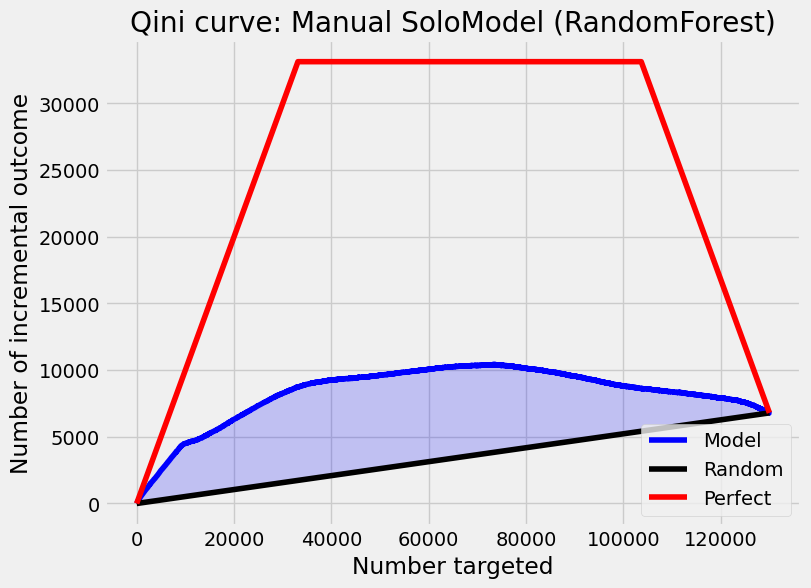

SoloModel (GBDT): Qini AUC = 0.17203


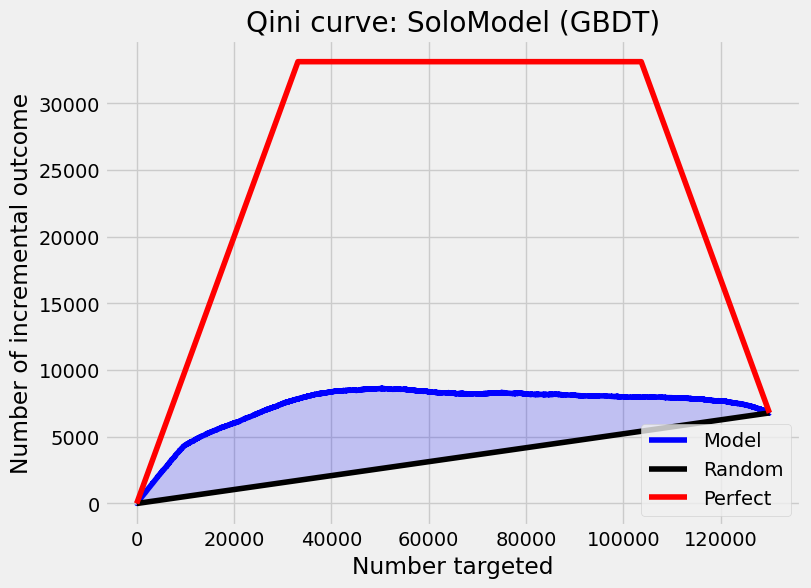

ClassTransformation (LogReg): Qini AUC = 0.15067


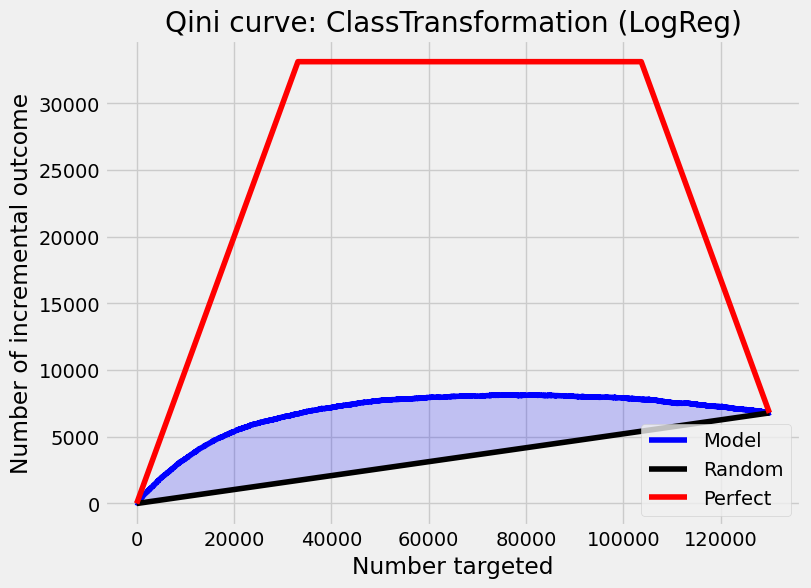

ClassTransformation (Calibrated LR): Qini AUC = 0.15054


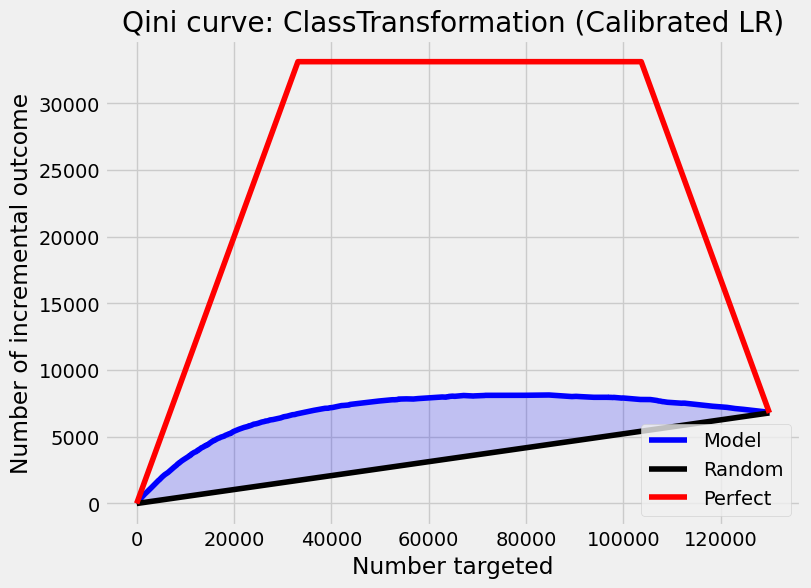

UpliftRandomForest (baseline): Qini AUC = 0.17097


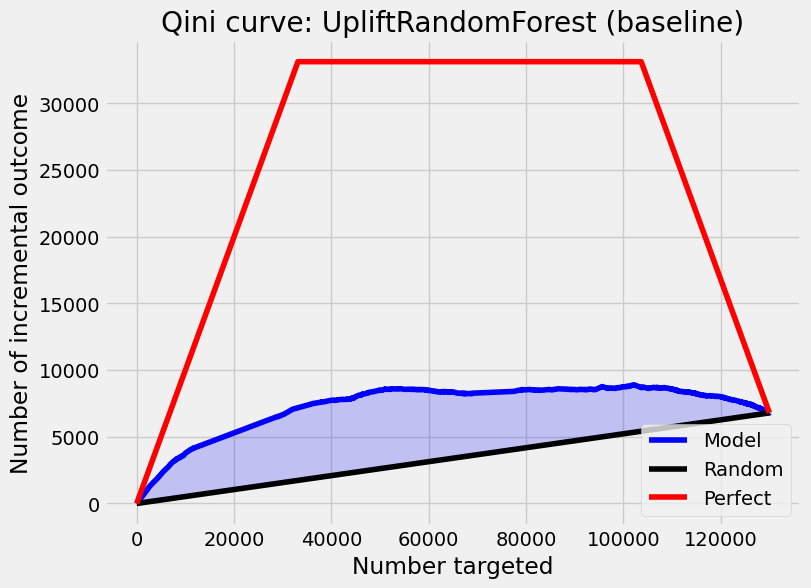

[I 2025-11-23 21:18:33,776] A new study created in memory with name: no-name-2252bf93-ef37-4fce-891d-20521021166e
[I 2025-11-23 21:24:29,812] Trial 0 finished with value: 0.19647182724042406 and parameters: {'n_estimators': 74, 'max_depth': 7, 'min_samples_leaf': 130}. Best is trial 0 with value: 0.19647182724042406.
[I 2025-11-23 21:30:27,614] Trial 1 finished with value: 0.19747382756112142 and parameters: {'n_estimators': 75, 'max_depth': 7, 'min_samples_leaf': 195}. Best is trial 1 with value: 0.19747382756112142.
[I 2025-11-23 21:34:03,337] Trial 2 finished with value: 0.15047856660021888 and parameters: {'n_estimators': 93, 'max_depth': 3, 'min_samples_leaf': 134}. Best is trial 1 with value: 0.19747382756112142.
[I 2025-11-23 21:46:36,613] Trial 3 finished with value: 0.20986204787592777 and parameters: {'n_estimators': 136, 'max_depth': 8, 'min_samples_leaf': 183}. Best is trial 3 with value: 0.20986204787592777.
[I 2025-11-23 21:49:43,904] Trial 4 finished with value: 0.169772

Лучшие параметры URF (optuna): {'n_estimators': 136, 'max_depth': 8, 'min_samples_leaf': 183}
Лучший Qini AUC URF: 0.20986204787592777
UpliftRandomForest (tuned): Qini AUC = 0.20986


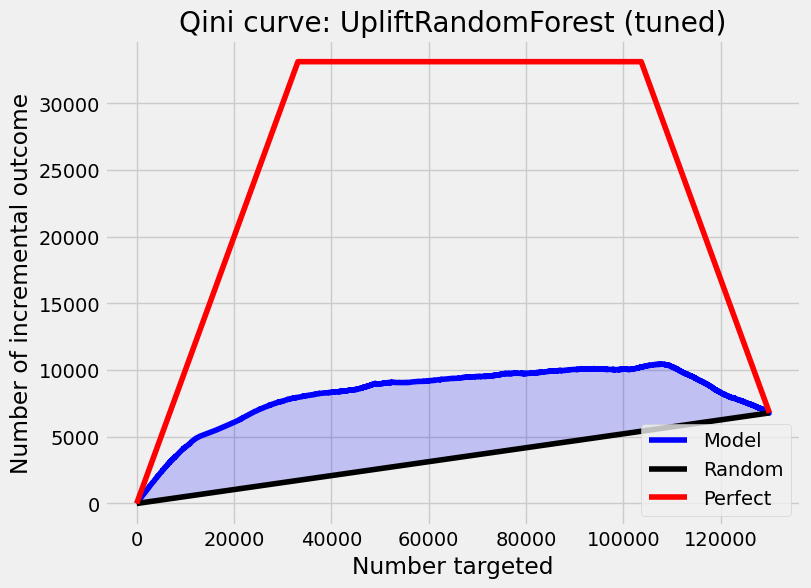

Итоговые Qini AUC по моделям:


,model,qini_auc
0,Manual_Solo_RF,0.211702
5,UpliftRandomForest_tuned,0.209862
1,SoloModel_GBDT,0.172034
4,UpliftRandomForest_baseline,0.170972
2,ClassTransformation_LogReg,0.150669
3,ClassTransformation_CalibratedLogReg,0.150542


In [13]:
RANDOM_STATE = 42
num_cols = [c for c in df_model_ok.columns if c.startswith('x')]
if 'age' in df_model_ok.columns:
    num_cols.append('age')

cat_cols = []
if 'city' in df_model_ok.columns:
    cat_cols.append('city')

X_all = df_model_ok[num_cols + cat_cols].copy()
y_all = df_model_ok['target'].astype(int).values
t_all = df_model_ok['is_treatment'].astype(int).values

strat = df_model_ok['target'].astype(str) + '_' + df_model_ok['is_treatment'].astype(str)

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_all, y_all, t_all,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=strat
)

preprocess = ColumnTransformer(
  transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
  ]
)

X_train_tr = preprocess.fit_transform(X_train)
X_test_tr  = preprocess.transform(X_test)

def eval_model(name, uplift_pred):
  qini = qini_auc_score(y_true=y_test,
                        uplift=uplift_pred,
                        treatment=t_test)
  print(f'{name}: Qini AUC = {qini:.5f}')

  plot_qini_curve(
      y_true=y_test,
      uplift=pd.Series(uplift_pred, index=X_test.index),
      treatment=pd.Series(t_test, index=X_test.index),
  )
  plt.title(f'Qini curve: {name}')
  plt.show()

  return qini

results = {}

X_train_solo = X_train.copy()
X_train_solo['treatment_group_key'] = t_train

X_test_1 = X_test.copy()
X_test_1['treatment_group_key'] = 1

X_test_0 = X_test.copy()
X_test_0['treatment_group_key'] = 0

num_cols_solo = num_cols + ['treatment_group_key']

preprocess_solo = ColumnTransformer(
  transformers=[
      ('num', StandardScaler(), num_cols_solo),
      ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
  ]
)

X_train_solo_tr = preprocess_solo.fit_transform(X_train_solo)
X_test_1_tr     = preprocess_solo.transform(X_test_1)
X_test_0_tr     = preprocess_solo.transform(X_test_0)

rf = RandomForestClassifier(
  n_estimators=200,
  max_depth=None,
  min_samples_leaf=50,
  random_state=RANDOM_STATE,
  n_jobs=-1
)

rf.fit(X_train_solo_tr, y_train)
p1 = rf.predict_proba(X_test_1_tr)[:, 1]
p0 = rf.predict_proba(X_test_0_tr)[:, 1]
uplift_manual = p1 - p0

results['Manual_Solo_RF'] = eval_model('Manual SoloModel (RandomForest)', uplift_manual)

solo = SoloModel(
  estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
  method='treatment_interaction'
)

solo.fit(X_train_tr, y_train, treatment=t_train)
uplift_solo = solo.predict(X_test_tr)

results['SoloModel_GBDT'] = eval_model('SoloModel (GBDT)', uplift_solo)

ct = ClassTransformation(
    estimator=LogisticRegression(max_iter=1000)
)

ct.fit(X_train_tr, y_train, treatment=t_train)
uplift_ct = ct.predict(X_test_tr)

results['ClassTransformation_LogReg'] = eval_model('ClassTransformation (LogReg)', uplift_ct)

base_lr = LogisticRegression(max_iter=1000)
cal_lr = CalibratedClassifierCV(
    estimator=base_lr,
    cv=3,
    method='isotonic'
)

ct_cal = ClassTransformation(estimator=cal_lr)
ct_cal.fit(X_train_tr, y_train, treatment=t_train)
uplift_ct_cal = ct_cal.predict(X_test_tr)

results['ClassTransformation_CalibratedLogReg'] = eval_model('ClassTransformation (Calibrated LR)', uplift_ct_cal)

t_train_str = np.where(t_train == 1, 'treatment', 'control')
t_test_str  = np.where(t_test  == 1, 'treatment', 'control')

urf = UpliftRandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=100,
    control_name='control',
    random_state=RANDOM_STATE
)

urf.fit(X=X_train_tr, treatment=t_train_str, y=y_train)
uplift_urf = urf.predict(X=X_test_tr)
uplift_urf = uplift_urf.reshape(-1) if hasattr(uplift_urf, 'reshape') else uplift_urf

results['UpliftRandomForest_baseline'] = eval_model('UpliftRandomForest (baseline)', uplift_urf)

def objective(trial):
  n_estimators = trial.suggest_int('n_estimators', 50, 150)
  max_depth = trial.suggest_int('max_depth', 3, 10)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 50, 200)

  model = UpliftRandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    control_name='control',
    random_state=RANDOM_STATE
  )
  model.fit(X_train_tr, treatment=t_train_str, y=y_train)
  uplift_pred = model.predict(X_test_tr)
  uplift_pred = uplift_pred.reshape(-1) if hasattr(uplift_pred, 'reshape') else uplift_pred

  return qini_auc_score(y_true=y_test,uplift=uplift_pred,treatment=t_test)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=False)

print('Лучшие параметры URF (optuna):', study.best_params)
print('Лучший Qini AUC URF:', study.best_value)

best_params = study.best_params
urf_best = UpliftRandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    control_name='control',
    random_state=RANDOM_STATE
)

urf_best.fit(X_train_tr, treatment=t_train_str, y=y_train)
uplift_best = urf_best.predict(X_test_tr)
uplift_best = uplift_best.reshape(-1) if hasattr(uplift_best, 'reshape') else uplift_best

results['UpliftRandomForest_tuned'] = eval_model('UpliftRandomForest (tuned)', uplift_best)

res_df = (
  pd.DataFrame(
      [{'model': k, 'qini_auc': v} for k, v in results.items()]
  ).sort_values('qini_auc', ascending=False)
)

print('Итоговые Qini AUC по моделям:')
display(res_df)

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [15]:
df_score = df_model_ok[['user_id', 'report_dt'] + num_cols + cat_cols].copy()
X_score_t1_raw = df_score[num_cols + cat_cols].copy()
X_score_t1_raw['treatment_group_key'] = 1

X_score_t0_raw = df_score[num_cols + cat_cols].copy()
X_score_t0_raw['treatment_group_key'] = 0

X_score_t1 = preprocess_solo.transform(X_score_t1_raw)
X_score_t0 = preprocess_solo.transform(X_score_t0_raw)

p1 = rf.predict_proba(X_score_t1)[:, 1]
p0 = rf.predict_proba(X_score_t0)[:, 1]
uplift_pred = p1 - p0

df_score['uplift'] = uplift_pred
best_channel = 'push'
df_score['channel'] = np.where(df_score['uplift'] > 0,best_channel,'no_comm')
answer = df_score[['user_id', 'report_dt', 'channel', 'uplift']]
answer.head()

,user_id,report_dt,channel,uplift
0,1,2024-09-30,no_comm,-0.034361
1,1,2024-09-30,no_comm,-0.034361
2,2,2024-09-30,push,0.476887
3,3,2024-09-30,push,0.039704
4,4,2024-09-30,no_comm,-0.050018


Сформирован финальный датасет с колонками:
user_id, report_dt, channel, uplift.
Коммуникации отправляются только клиентам с uplift > 0, выбранный канал -тот, который даёт максимальный uplift. Клиентам с uplift <= 0 рекомендуется не отправлять коммуникацию.

Финальный вывод: все этапы работы выполнены: сбор таргета, очистка кампаний, присоединение агрегатов, построение uplift-моделей, тюнинг и скоринг клиентов.
Лучшие модели: Manual_Solo_RF и UpliftRandomForest_tuned.
Финальный скоринг подготовлен.